# College Scorecard Provisional Analysis (DOE) 

Hypothesis 1 (College Scorecard): Students who attend more racially and demographically diverse universities will demonstrate higher median earnings after graduation, reflecting the broad economic and social benefits of diverse educational environments.

- Expect that more homogenous universities (excl. HBCU's) will have worse outcomes for students
- Control for: family income distribution, completion rates


In [1]:
#setup chunk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from IPython.display import IFrame
import statsmodels.formula.api as smf

In [2]:
#data cleaning process-- especially making smaller datasets that are more manageable and only include relevant variables

dat = pd.read_csv('../data/Glynn_data/combined_data.csv')
dat.columns

Index(['univ_id', 'univ_name', 'state', 'zip_code', 'percent_pell',
       'completion_rate_fry', 'ugds_white', 'ugds_black', 'ugds_hisp',
       'ugds_asian', 'ugds_aian', 'ugds_nhpi', 'ugds_2mor', 'ugds_nra',
       'ugds_unkn', 'ugds_men', 'ugds_women', 'md_earn_wne_4yr', 'year',
       'hbcu', 'pbi', 'aanapii', 'hsi', 'tribal', 'long', 'all_male',
       'all_female', 'admit_rate', 'lat', 'pct_w_ba_hometown', 'degree_type'],
      dtype='str')

## Variable Descriptions: 
The dataset includes a few different variables which relate to the general diversity of the institution, especially the rates of different racial/ ethnic groups in the university. In addition to the composition of the university based on these groups, there is also information on whether a university is a Historically Black College or University (hbcu), or a predominantly black institution (40%+ of student body is Black). Similar tags are provided for other groups, for example, Hispanic Serving Institutions (HSIs) are defined by The Higher Education Act as not-for-profit colleges and universities where at least 25% of the full-time equivalent undergraduate enrollment is Hispanic. A few control variables are alsoc included. For example the *percent_pell* varibale refers to the percent of the school receiving pell grants, while *admit_rate* refers to the admission rate of a universtiy, with higher admit rates indicatingthat a school is less exclusive, generally. Furthermore, we have each university name, its state and zip code, and its completion rate. Most importantly for the analysis, there is also a varible which tracks the and the median earnings of students four years after graduation. 


- ugds_: different racial/ demographic variables of the student body at a university. Intuitively coded as ugds_suffix, where the suffix is the group (white, black, hispanic, asian, amarican indian and alaska native, native hawaiian and pacific islander, two or more races, norace, unknown, white nonhispanic, blacknonhispanic, asian pacific islander)
- md_earn_wne_4yr: Median earnings are calculated for individuals that were federally aided, were working, and were not enrolled in school as of the measurement point. Earnings were measured based on wages and deferred compensation reported via IRS form W-2 plus positive self-employment earnings reported via Schedule SE. Individuals with $1 or more of earnings were considered to be working and were included in the median earnings calculation.
- pct_w_ba_hometown: Percent of the population from students' zip codes with a bachelor's degree over the age 25, via Census data
- degree_type: Predominant undergraduate degree awarded: 0 Not classified, 1 Predominantly certificate-degree granting, 2 Predominantly associate's-degree granting, 3 Predominantly bachelor's-degree granting,  4 Entirely graduate-degree granting"
- completion_rate_fry: Completion rate for four year institutions 


In [3]:
#other dataset features
#dat.info()
dat['degree_type'].unique()

array([3, 1, 2, 4, 0])

There are 6,159 total universities in the dataset, but when accounting for the number of universities that are outside of the uppermost-50 (excluding Guam and Puerto Rico which do not have full statehood), the numbers change slightly...

In [4]:
#then narrow only to universities in upper-50 US (no PR or Guam)
dat['state'].value_counts()
non_50 = ['VI', 'AS', 'MP', 'FM', 'PW', 'MH', 'GU', 'PR']
    #virgin islands, american samoa, northern marina islands, federated state of micronesia, palao, guam, puerto rico

dat[~dat['state'].isin(non_50)].nunique() #taking out states not in the 50 states gives us 51 unique states (since the dataset includes DC)
#filtering
dat = dat[~dat['state'].isin(non_50)]

After filtering only to the 'upper-50' states, including Washington DC, there are 6,009 unique universities, 150 less than in the original dataset.

In [5]:
#narrow to predominantly undergraduate-degree granting universities
dat['degree_type'].value_counts() 
#there are about 1898 unique observations of this type

degree_type
1    2499
3    1898
2     949
0     398
4     265
Name: count, dtype: int64

In [6]:
dat[dat['degree_type']==3].nunique()
#dat[dat['univ_name'].duplicated()] #this line of code demonstrates that 
    #the higher number of university IDs relative to the number of university names is due to repeated names (e.g. Bethel University)


univ_id                1898
univ_name              1886
state                    51
zip_code               1832
percent_pell           1577
completion_rate_fry    1407
ugds_white             1600
ugds_black             1291
ugds_hisp              1349
ugds_asian              877
ugds_aian               261
ugds_nhpi               166
ugds_2mor               710
ugds_nra                821
ugds_unkn               766
ugds_men               1452
ugds_women             1452
md_earn_wne_4yr        1584
year                      1
hbcu                      2
pbi                       2
aanapii                   2
hsi                       2
tribal                    2
long                   1879
all_male                  2
all_female                2
admit_rate             1335
lat                    1880
pct_w_ba_hometown       959
degree_type               1
dtype: int64

In [7]:
#keep only 4-yr institutions
dat = dat[dat['degree_type']==3]

After filtering non-undergraduate universities, there are 1,942 universities in the dataset. 


Since I expect that students who attend more racially and demographically diverse universities will demonstrate higher median earnings after graduation, we might expect to see some visual connection between the racial composition of a unviersity and our key outcome variable.


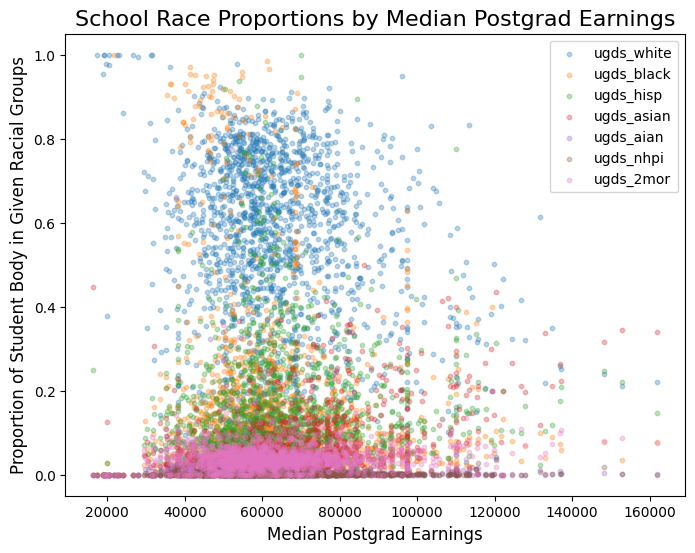

In [8]:
race_cols = ['ugds_white', 'ugds_black', 'ugds_hisp', 'ugds_asian', 'ugds_aian', 
             'ugds_nhpi', 'ugds_2mor']

#convert the IV to numeric: 
dat['md_earn_wne_4yr'] = pd.to_numeric(dat['md_earn_wne_4yr'], errors='coerce')


fig, ax = plt.subplots(figsize = (8,6))

for col in race_cols: 
    ax.scatter(dat['md_earn_wne_4yr'], dat[col], label=col, alpha=0.3, s=10)

ax.set_title("School Race Proportions by Median Postgrad Earnings", fontsize = 16)
ax.set_xlabel('Median Postgrad Earnings', fontsize=12)
ax.set_ylabel('Proportion of Student Body in Given Racial Groups', fontsize=12)
plt.legend()

plt.show()

In this graph, each point represents the composition of a different racial group for a given university. 

If we did see an effect of *individual* racial groups on postgrad earnings, we would expect a classic linear relationship, where as the proportion of a racial group increases, so do the median postgrad earnings. This is somewhat visible at the tail of the Asian American group (pink), where after the earning threshold of 80,000, the earnings seem to increase sas the percent of Asian Americans does at a school. There is a opposite, albeit less strong relationship, at the right end of the right side of White postgrad earnings.

From this graph, it's impossible to tell whether as the proportion of a racial group close to 80% or higher increases, the colleges' expected median earnings do too. The relative lack of data in the top right corner seems to somewhat support the hypothesis that earnings correlate with greater diversity, with the highest-earning schools seeming to have a somewhat equally distributed mix of races between 0-0.4% of their student body.  

The first graph demonstrates a few patterns/ outliers to explore and correct here: 
1. There are quite a few dots clustered at the top of the distribution at exactly 1, indicating completely white and one completely Black university. The Black outlier might represent an HBCU, while the White and Hispanic outliers warrant further explanation.  
2. The points at the far right end of the graph (higher earnings) seem to resemble one another. Check what universities these are, and what their racial composition is. My guess is that highly selective universities can tailor their student body to be some combination of representative and diverse in a way that less seelctive universities (who probably have worse earning outcomes) cannot.  

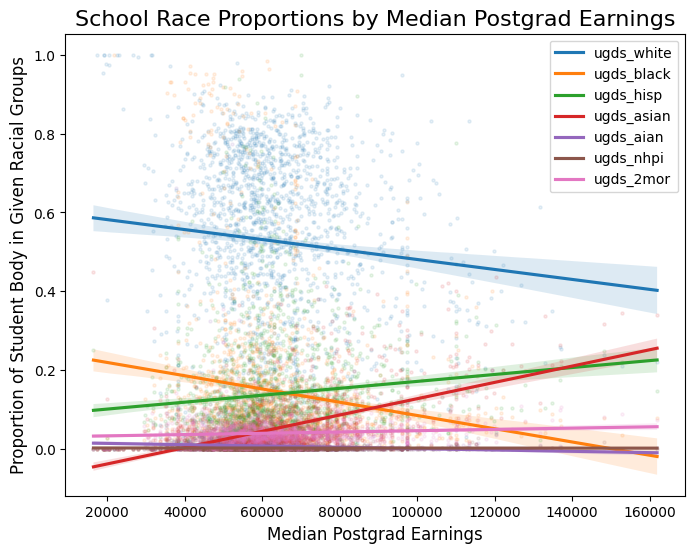

In [9]:
#changing to a regression plot to see clearer trends between racial groups

fig, ax = plt.subplots(figsize = (8,6))

for col in race_cols: 
    sns.regplot(data = dat, x = 'md_earn_wne_4yr', y = col,  
                scatter_kws = {'alpha': 0.1, 's':5}, 
                line_kws = {'label': col}, 
                ax = ax)

ax.set_title("School Race Proportions by Median Postgrad Earnings", fontsize = 16)
ax.set_xlabel('Median Postgrad Earnings', fontsize=12)
ax.set_ylabel('Proportion of Student Body in Given Racial Groups', fontsize=12)
plt.legend()

plt.show()

The regression lines added to the plot demonstrate the average trend in earnings increases according to the proportion of a student body in a given racial group. 

Schools with high populations of Asian students tend to report better median earnings for their students later on. We might explain this through racial biases in the labor market, and the socioeconomically advantaged position of White and Asian Americans for the most part, who are overrepresetned in the [middle and upper classes](https://www.pewresearch.org/race-and-ethnicity/2024/05/31/the-state-of-the-asian-american-middle-class/), with respect to their proportions in the populaition. Schools with higher populations of Hispanic students also seem to have higher average median earnings, although to a lesser extent than is the case with Asian Americans. 

Conversely, among schools who have higher shares of Black and White students, median earnings tend to go down. In particular, it seems that schools with disproportionately white student bodies (above 70 percent) are clustered at the lower end of the earnings spectrum, while schools with significantly higher earnings have White student populations around 40%. The similar trend for Black students might be attributed, instead to the relatively low proportion of Black students represented in the universities at the higher end of the postgrad earnings spectrum.  

In [10]:
#make a designated label for hbcus and other special racially designated universities on the graph 
#identify hbcus, etc. 
n_hsi = len(dat[dat['hsi']>=0.98]) #249 Hispanic serving institutions
n_hbcu = len(dat[dat['hbcu']>=0.98]) #83 hbcus
n_tribal = len(dat[dat['tribal']>=0.98]) #2 tribal universities
n_pbi = len(dat[dat['pbi']>=0.98]) #19 primarily black institutions

#make an output table of these values 
tab = pd.DataFrame({
    'University Designation': ['Hispanic Serving Institution (HSI)', 
                              'Historically Black College/University (HBCU)', 
                              'Tribal University', 
                              'Predominantly Black Institution'], 
    'Number of Universities': [n_hsi, n_hbcu, n_tribal, n_pbi]
})

print(tab)

                         University Designation  Number of Universities
0            Hispanic Serving Institution (HSI)                     249
1  Historically Black College/University (HBCU)                      83
2                             Tribal University                       2
3               Predominantly Black Institution                      19


Certain universities are intentionally designated to serve particular minorities, for example, [Hispanic-Serving Institutions (HSIs)](https://www.ed.gov/about/ed-offices/ope/hispanic-serving-institutions-division--home-page) receive special grant funding from the DOE to assist with strengthening institutional programs, facilities, and services to expand the educational opportunities for Hispanic Americans and other underrepresented populations. Furthermore, the DoE supports 107 Historically Black Colleges and Universities (HBCUs) through targeted grant programs, capital financing, and the White House Initiative on HBCUs, which works to advance educational equity and increase federal funding access. 

For these universities, where racial imbalances may intentionally attempt to address inequities experienced by certain groups, we might expect that outcomes are different, and perhaps better than their counterparts that do not receive special funding. 

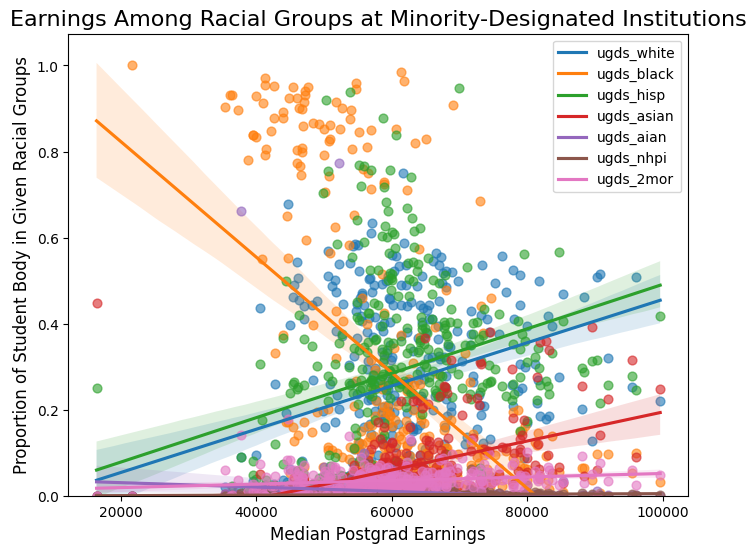

In [26]:
#regraph but plot racially designated universities with different symbols. 
designated = (dat['hsi'] >= 0.98)  | (dat['tribal'] >= 0.98) | (dat['hbcu'] >= 0.98) | (dat['pbi'] >= 0.98)

#did this by splitting the dataset into two 
dat_designated = dat[designated]
fig, ax = plt.subplots(figsize=(8, 6))

for col in race_cols:
    sns.regplot(data=dat_designated, x='md_earn_wne_4yr', y=col,
                scatter_kws={'alpha': 0.6, 's': 40, 'marker': '*'},
                line_kws={'label': col},
                ax=ax)
ax.set_ylim(bottom=0)
ax.set_title("Earnings Among Racial Groups at Minority-Designated Institutions", fontsize=16)
ax.set_xlabel('Median Postgrad Earnings', fontsize=12)
ax.set_ylabel('Proportion of Student Body in Given Racial Groups', fontsize=12)
plt.legend()
plt.show()

The graph above demonstrates that unlike we expected, designating a university as an HBCU, Tribal, HSI, or PBI does not universally increase the relationship between the proportion of a racial group at a university and the earnings of that university. Instead, it appears that institutions with a high proportion of Black students may benefit less from these designations than those with high Hispanic populations. Counterintuitively, it seems that designated universities at the higher end of the earnings spectrum may also have higher proportions of White students. 

The takeaway from this graph may be that diversity, rather than high proportions of a particular racial group are likely to be correlated with better student outcomes, even if a university receives more funding to address structural inequalities experienced by that group. 

In [29]:
#investigating these relationships numerically
#for model including all universities
for col in race_cols: 
    model = smf.ols(f'md_earn_wne_4yr ~ {col}', data = dat).fit()
#    print(model.summary())

In [30]:
#investigating these relationships numerically
#for model including only racially designated universities
for col in race_cols: 
    model = smf.ols(f'md_earn_wne_4yr ~ {col}', data = dat_designated).fit()
#    print(col)
#    print(model.summary())

In [28]:
#asked claude to help me make a summary table to put all the regression results in one place so it was easier to read: 
results = []

for col in race_cols:
    model_all = smf.ols(f'md_earn_wne_4yr ~ {col}', data=dat).fit()
    model_des = smf.ols(f'md_earn_wne_4yr ~ {col}', data=dat_designated).fit()
    
    results.append({
        'Racial Group':    col,
        'Slope (All)':     f"{model_all.params[col]:,.0f}",
        'R² (All)':        f"{model_all.rsquared:.3f}",
        'p-value (All)':   f"{model_all.pvalues[col]:.3f}",
        'Slope (Designated)': f"{model_des.params[col]:,.0f}",
        'R² (Designated)':    f"{model_des.rsquared:.3f}",
        'p-value (Designated)': f"{model_des.pvalues[col]:.3f}",
    })

summary = pd.DataFrame(results)
summary['Racial Group'] = race_col_names  # swap in your readable names
summary

,Racial Group,Slope (All),R² (All),p-value (All),Slope (Designated),R² (Designated),p-value (Designated)
0,White Undergraduates,"-6,757",0.009,0.000,"21,104",0.106,0.000
1,Black Undergraduates,"-14,074",0.024,0.000,"-19,609",0.264,0.000
2,Hispanic Undergraduates,"14,026",0.012,0.000,"18,601",0.096,0.000
3,Asian Undergraduates,"127,842",0.264,0.000,"75,824",0.256,0.000
4,Native American Undergraduates,"-55,165",0.009,0.000,"-23,664",0.012,0.044
5,NHPI Undergraduates,"-11,674",0.000,0.807,"330,684",0.019,0.012
6,Undergraduates of 2 or More Races,"58,838",0.010,0.000,"96,723",0.040,0.000


The first set of regressions, including all universities, tells us that schools with higher proportions of White, Black, Native American, or NHPI tend to have lower median earnings than schools with lower values for these races. In the case of Hispanic, Asian American, or 2 or more races, universities tend to report higher average earnings in conjunction with higher proportions of these groups. This relationship is significant in all groups, except Native Hawaiian and Pacific islanders. 

The slope values each indicate the expected rise or decline in earnings at a university for each percent of a racial group that the university increases. For example, schools with one percent higher Hispanic undergraduate populations have higher median earnings by about $14,000 dollars. This is equivalent to a year's worth of [childcare](https://tootris.com/edu/blog/parents/child-care-cost-15080-a-year-pennsylvania-heres-the-breakdown/#:~:text=On%20average%2C%20parents%20can%20expect%20to%20pay,care%20and%20around%20$7%2C000%20to%20$10%2C000%20per) in Philadelphia. 

The second set of regression results, from designated universities, indicate that the relationship is different for expected earnings of White students 

Importantly, these numbers are not perscriptive, but descriptive. That is, schools do not necessarily increase their median earnings by increasing or decreasing the number of students at their school in a particular racial group. For this reason, it is important to include controls for other variables that might affect the relationship between structural aspects of income inequality between universities, such as the number of students who originate from low income backgrounds, the exclusivity of the university, and the completion rate of a university. 



transition: is this different for universities that 

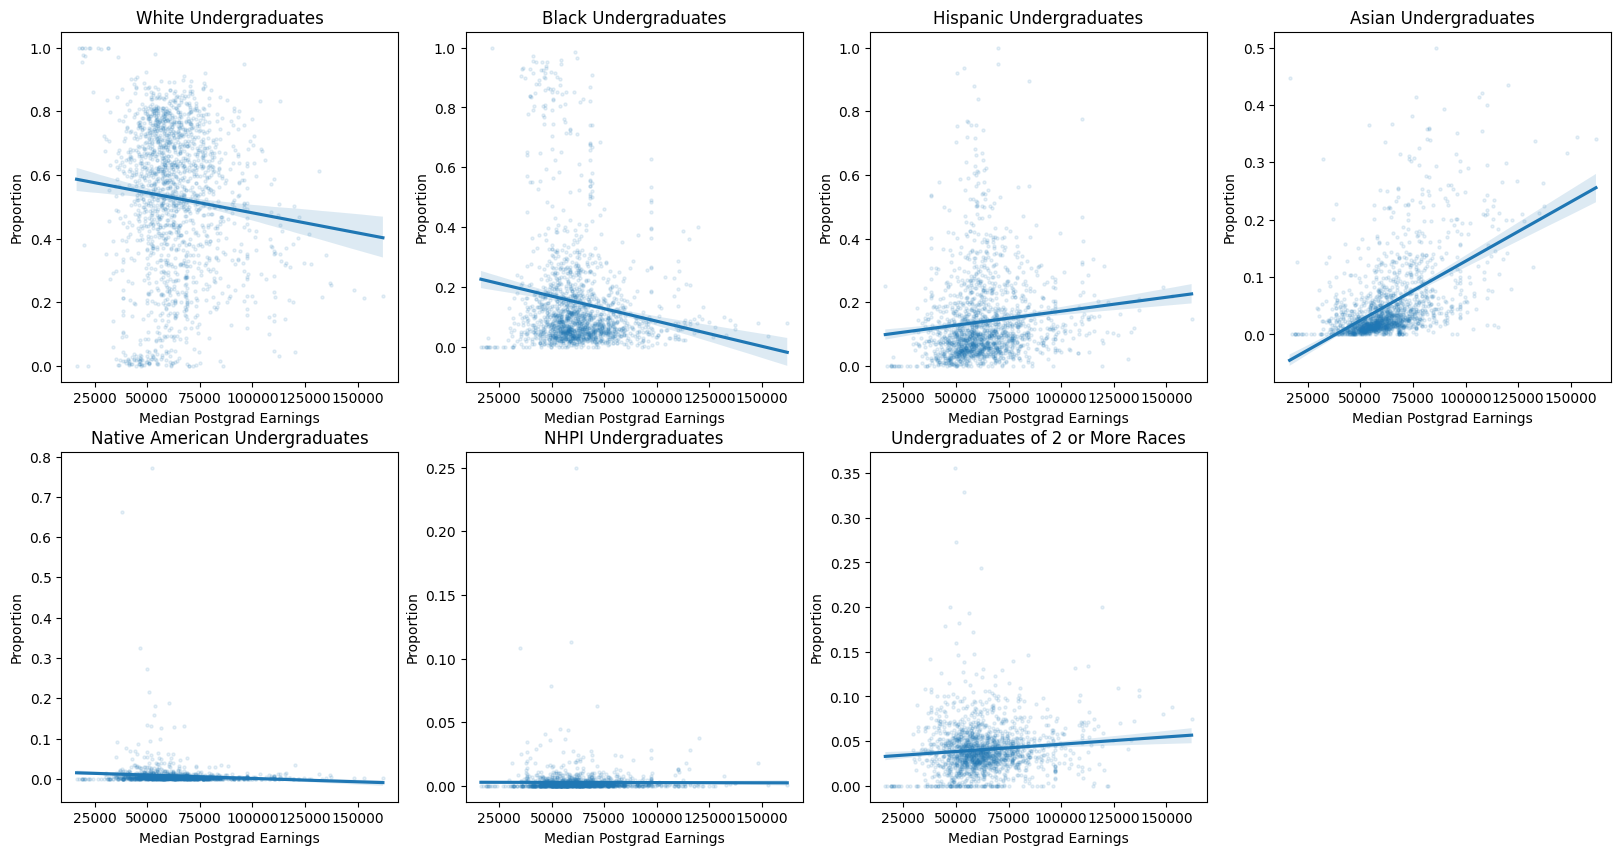

In [15]:
#the goal is to make a faceted graph for each of the racial groups
    #each graph willl have a horizontal line for the proportion of that group in the population
    #then there will be specially shaped dots to represent universities specifically designated by the DOE as hbcus, hsis, etc. 
    #have a label for the regression line 
race_cols = ['ugds_white', 'ugds_black', 'ugds_hisp', 'ugds_asian', 'ugds_aian', 'ugds_nhpi', 'ugds_2mor']
race_col_names = ['White Undergraduates', 'Black Undergraduates', 'Hispanic Undergraduates' ,'Asian Undergraduates', 
                 'Native American Undergraduates', 'NHPI Undergraduates', 'Undergraduates of 2 or More Races']
#asked claude for help learning how to facet the graph
fig, axes = plt.subplots(nrows = 2, ncols =4, figsize = (20,10)) #make a grid of axes
axes = axes.flatten() #make the axes into a list

for i, col in enumerate(race_cols): #where enumerate is adding a counter to an 
        #object that I'm iterating over, in this case, race_cols
    sns.regplot(data = dat, x = 'md_earn_wne_4yr', y = col,  
                scatter_kws = {'alpha': 0.1, 's':5}, 
                line_kws = {'label': col}, 
                ax = axes[i])
    axes[i].set_title(race_col_names[i])
    axes[i].set_xlabel('Median Postgrad Earnings')
    axes[i].set_ylabel('Proportion')
axes[-1].set_visible(False) #get rid of the last axis
    
plt.show()

In [16]:
##Investigate universities who are outliers in percent of student body == 1

In [17]:
dat[dat['ugds_white']>=.99].head()

,univ_id,univ_name,state,zip_code,percent_pell,completion_rate_fry,ugds_white,ugds_black,ugds_hisp,ugds_asian,...,aanapii,hsi,tribal,long,all_male,all_female,admit_rate,lat,pct_w_ba_hometown,degree_type
2012,190752,Yeshiva of Far Rockaway Derech Ayson Rabbinica...,NY,11691-5219,0.2000,0.3333,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-73.743901,0.0,0.0,0.9200,40.600490,NaN,3
2043,192165,Kehilath Yakov Rabbinical Seminary,NY,10562,0.8580,0.5000,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-73.814887,1.0,0.0,NaN,41.220521,11.6800003051757,3
2061,193052,Mesivta Torah Vodaath Rabbinical Seminary,NY,11218,0.3875,0.2857,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-73.969395,1.0,0.0,0.8000,40.638200,14.3999996185302,3
2063,193070,Mesivtha Tifereth Jerusalem of America,NY,10002-6301,0.5455,0.1053,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-73.991271,1.0,0.0,0.6000,40.713812,15.869999885559,3
2101,194657,Rabbinical Academy Mesivta Rabbi Chaim Berlin,NY,11230,0.1737,0.2368,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-73.963615,1.0,0.0,0.9362,40.618347,18.0400009155273,3


The universities that are predominantly white tend to be Rabinical seminaries, which makes sense, given that there are few Jewish people of color (given that Arab Americans are not included in the dataset, Mizrahi, or Jewish people of Arab origin are likely identified as White Americans). This also explains why these universities are clustered at lower ends of the earnings spectrum. It appears that Rabbis do not make very much money after graduation. 

In [18]:
dat[dat['ugds_black'] >=.90][['univ_name', 'completion_rate_fry', 'percent_pell', 'admit_rate', 'md_earn_wne_4yr']].head()

,univ_name,completion_rate_fry,percent_pell,admit_rate,md_earn_wne_4yr
4,Alabama State University,0.2773,0.6976,0.9755,45998.0
32,Miles College,0.2640,0.7447,NaN,NaN
42,Selma University,NaN,NaN,NaN,21666.0
47,Stillman College,0.2480,0.6989,0.6225,42622.0
51,Tuskegee University,0.6728,0.5723,0.4868,69077.0


In [19]:
dat[dat['ugds_hisp']>=.90][['univ_name', 'completion_rate_fry', 'percent_pell', 'admit_rate', 'md_earn_wne_4yr']].head()


,univ_name,completion_rate_fry,percent_pell,admit_rate,md_earn_wne_4yr
3081,Texas A & M International University,0.4945,0.6308,0.4437,50288.0
3107,The University of Texas Rio Grande Valley,0.5282,0.6222,0.9419,53888.0
4642,Polytechnic University of Puerto Rico-Miami,0.0000,0.6377,NaN,69903.0
4643,Polytechnic University of Puerto Rico-Orlando,0.2000,0.6032,NaN,69903.0


In [20]:
#Investigate the outliers at the upper end of the earnings

In [21]:
#looking at universities at the higher end of the earnings spectrum
dat[dat['md_earn_wne_4yr'] <=30000][['univ_name', 'completion_rate_fry', 'percent_pell', 'admit_rate', 'md_earn_wne_4yr']]

,univ_name,completion_rate_fry,percent_pell,admit_rate,md_earn_wne_4yr
42,Selma University,NaN,NaN,NaN,21666.0
1971,Central Yeshiva Tomchei Tmimim Lubavitz,0.1071,0.6464,0.8743,24036.0
2043,Kehilath Yakov Rabbinical Seminary,0.5000,0.8580,NaN,19057.0
2061,Mesivta Torah Vodaath Rabbinical Seminary,0.2857,0.3875,0.8000,22412.0
2102,Rabbinical College Bobover Yeshiva Bnei Zion,0.8776,0.8337,NaN,26701.0
2176,United Talmudical Seminary,0.5887,0.8630,NaN,18950.0
2194,Yeshivath Viznitz,0.7358,0.7782,NaN,19601.0
2640,Curtis Institute of Music,0.8333,0.0642,0.0458,20026.0
3211,Sterling College,0.2963,0.3730,0.6667,29415.0
3719,Yeshiva Gedolah Imrei Yosef D'spinka,0.5789,0.9154,NaN,17404.0


In [22]:
#looking at universities at the lower end of the earnings spectrum
dat[dat['md_earn_wne_4yr'] >=120000][['univ_name', 'completion_rate_fry', 'percent_pell', 'admit_rate', 'md_earn_wne_4yr']].head()

,univ_name,completion_rate_fry,percent_pell,admit_rate,md_earn_wne_4yr
187,California Institute of Technology,0.9404,0.1398,0.0257,152843.0
294,Harvey Mudd College,0.9202,0.1293,0.1266,137100.0
399,Samuel Merritt University,NaN,0.1827,NaN,148182.0
820,University of Chicago,0.9558,0.1294,0.0448,127757.0
1380,Harvard University,0.9777,0.1341,0.0365,134794.0


Investigating the first few rows of data from the higher ends of the earnings spectrum, the idea that more exclusive universities are on the far end of the spectrum is supported. Highly selective universities (UChicago and Harvard, for example), are joined by universities that deliver medical degrees. 

In [23]:
#Control for: family income distribution, completion rates, and the general exclusivity (admit rate)